# Coursework 1

This notebook is intended to be used as a starting point for your experiments. The instructions can be found in the MLP2025_26_CW1_Spec.pdf (see Learn,  Assignment Submission, Coursework 1). The methods provided here are just helper functions. If you want more complex graphs such as side by side comparisons of different experiments you should learn more about matplotlib and implement them. Before each experiment remember to re-initialize neural network weights and reset the data providers so you get a properly initialized experiment. For each experiment try to keep most hyperparameters the same except the one under investigation so you can understand what the effects of each are.

## Training Boilerplate

Use the below code as a boilerplate to start your experiments. You can add more cells or change the code as you see fit.

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import logging
# import sys
# sys.path.append('/path/to/mlpractical')

import os
os.environ['MLP_DATA_DIR'] = r"C:\Users\samue\mlpractical\data"

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer, DropoutLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser
from mlp.penalties import L1Penalty, L2Penalty, L1L2MixPenalty

In [17]:
%matplotlib inline
plt.style.use('ggplot')

def train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True):
    
    # As well as monitoring the error over training also monitor classification
    # accuracy i.e. proportion of most-probable predicted classes being equal to targets
    data_monitors={'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

    # Use the created objects to initialise a new Optimiser instance.
    optimiser = Optimiser(
        model, error, learning_rule, train_data, valid_data, data_monitors, notebook=notebook)

    # Run the optimiser for num_epochs epochs (full passes through the training set)
    # printing statistics every epoch.
    stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

    # Plot the change in the validation and training set error over training.
    fig_1 = plt.figure(figsize=(8, 4))
    ax_1 = fig_1.add_subplot(111)
    for k in ['error(train)', 'error(valid)']:
        ax_1.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_1.legend(loc=0)
    ax_1.set_xlabel('Epoch number')
    ax_1.set_ylabel('Error')

    # Plot the change in the validation and training set accuracy over training.
    fig_2 = plt.figure(figsize=(8, 4))
    ax_2 = fig_2.add_subplot(111)
    for k in ['acc(train)', 'acc(valid)']:
        ax_2.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_2.legend(loc=0)
    ax_2.set_xlabel('Epoch number')
    ax_2.set_xlabel('Accuracy')

    grad_plot, grad_ax = optimiser.plot_grad_flow()

    return stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax

In [18]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

KeysView(NpzFile 'C:\\Users\\samue\\mlpractical\\data\\emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile 'C:\\Users\\samue\\mlpractical\\data\\emnist-valid.npz' with keys: inputs, targets)


Note: you may need to restart the kernel to use updated packages.


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 9.0s to complete
    error(train)=1.03e-01, acc(train)=9.59e-01, error(valid)=1.58e+00, acc(valid)=8.17e-01


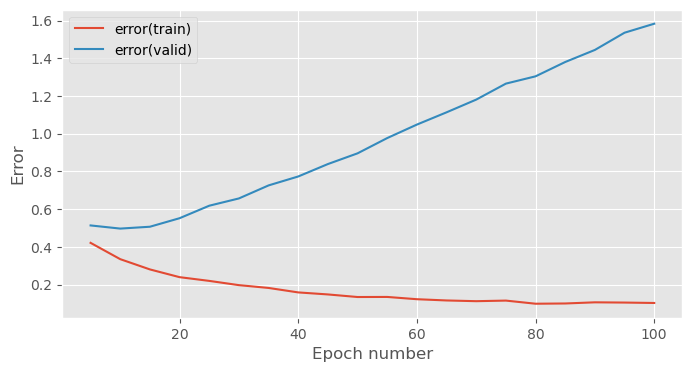

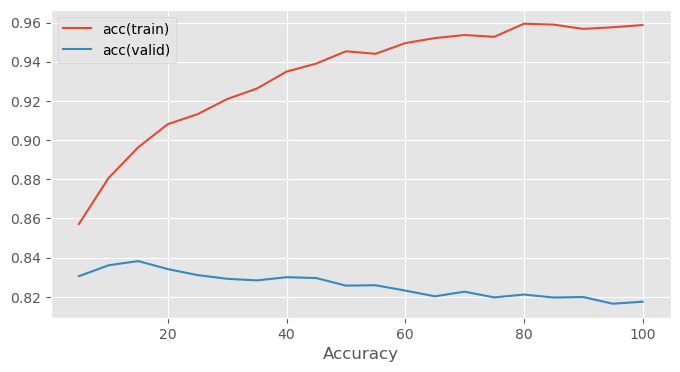

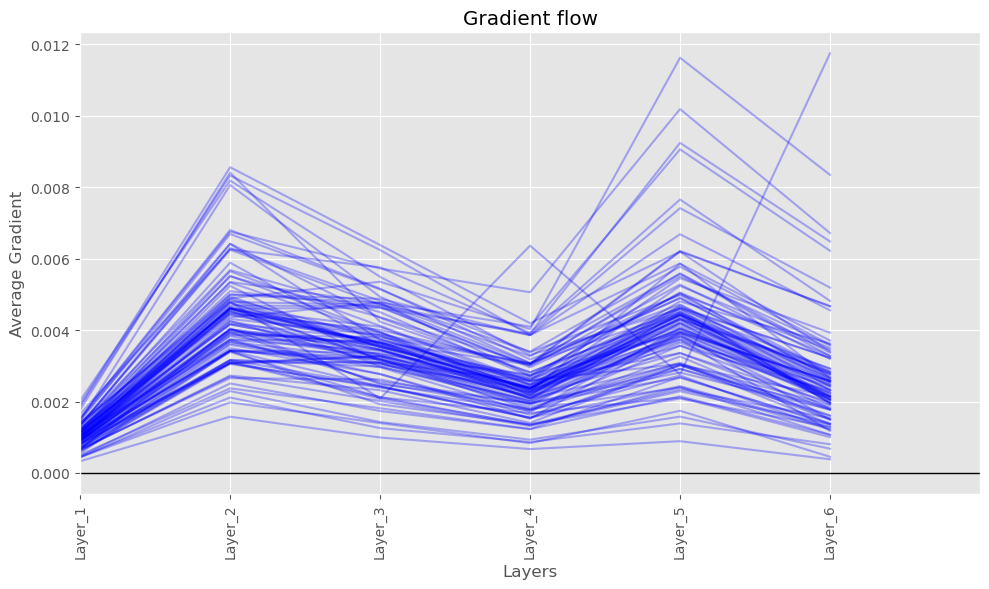

In [14]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.

%pip install tqdm

# Setup hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 5
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

Note: you may need to restart the kernel to use updated packages.


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 4.3s to complete
    error(train)=5.50e-01, acc(train)=8.25e-01, error(valid)=7.06e-01, acc(valid)=7.83e-01


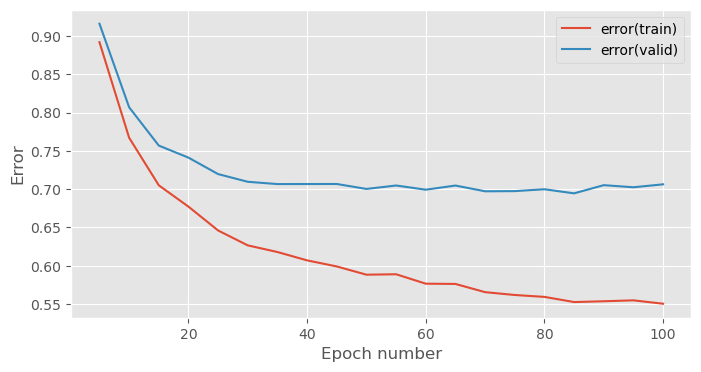

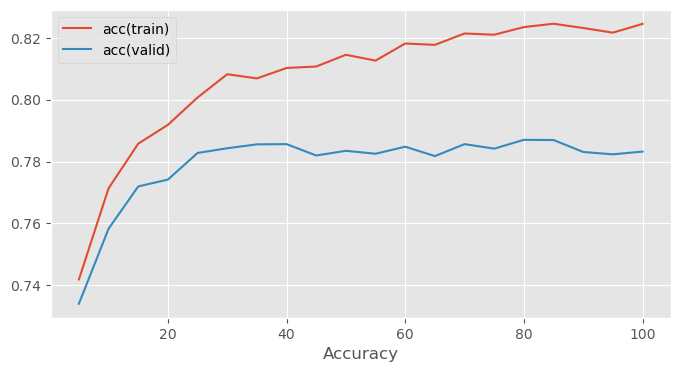

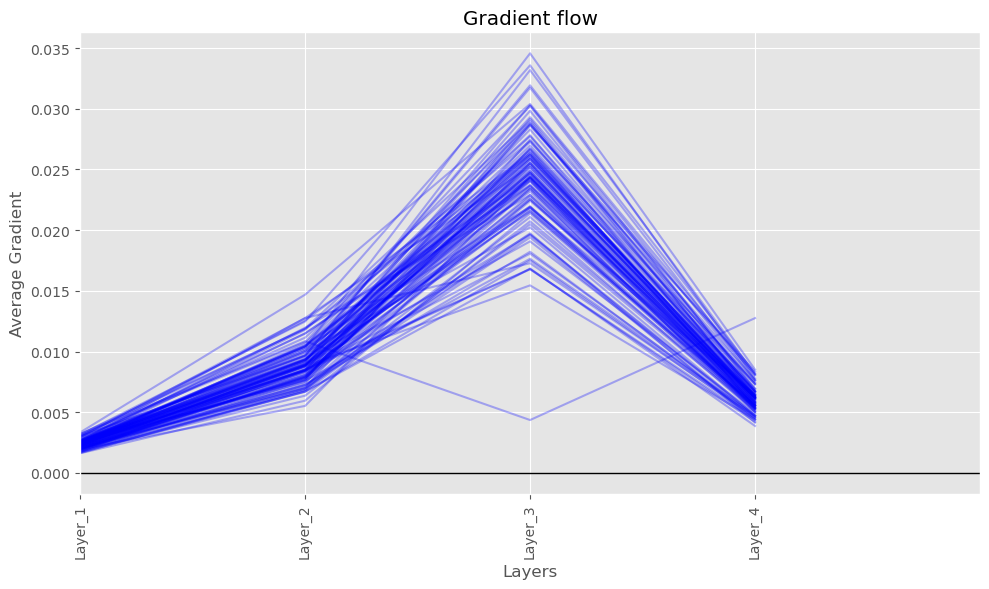

In [15]:
# SINGLE LAYER NETWORK WITH WIDTH 32 
%pip install tqdm

# Setup hyperparameters
learning_rate = 0.0009
num_epochs = 100
stats_interval = 5
input_dim, output_dim, hidden_dim = 784, 47, 32

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_28, keys, run_time, fig_1_32, ax_1_32, fig_2_32, ax_2_32, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

Note: you may need to restart the kernel to use updated packages.


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 6.1s to complete
    error(train)=3.51e-01, acc(train)=8.79e-01, error(valid)=6.65e-01, acc(valid)=8.09e-01


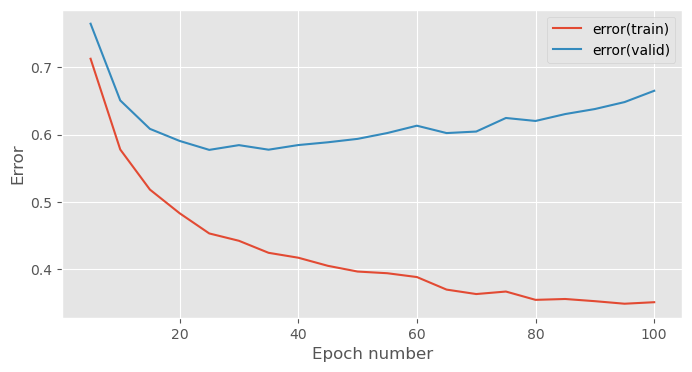

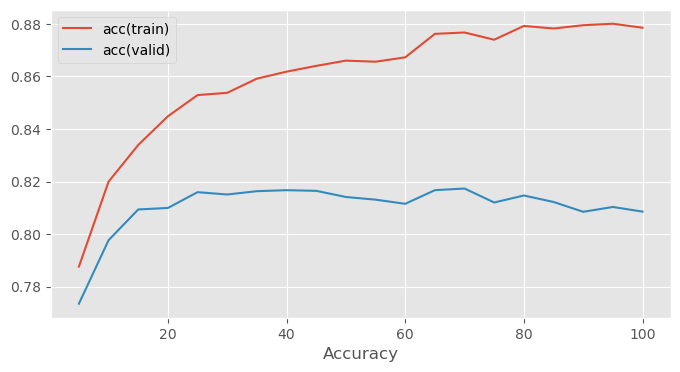

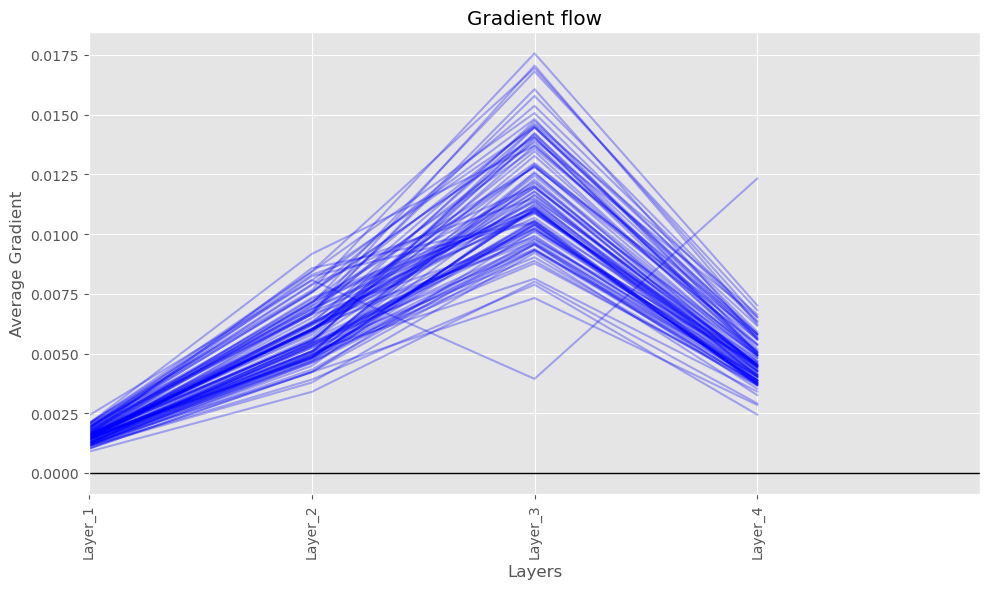

In [16]:
# SINGLE LAYER NETWORK WITH WIDTH 64
%pip install tqdm

# Setup hyperparameters
learning_rate = 0.0009
num_epochs = 100
stats_interval = 5
input_dim, output_dim, hidden_dim = 784, 47, 64

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_64, keys, run_time, fig_1_64, ax_1_64, fig_2_64, ax_2_64, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

Note: you may need to restart the kernel to use updated packages.


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 9.5s to complete
    error(train)=1.64e-01, acc(train)=9.38e-01, error(valid)=9.34e-01, acc(valid)=8.08e-01


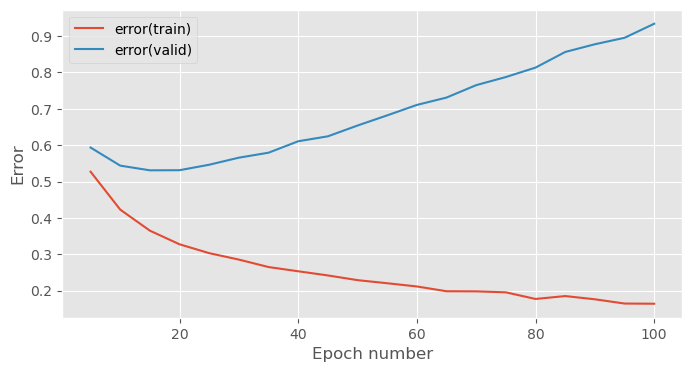

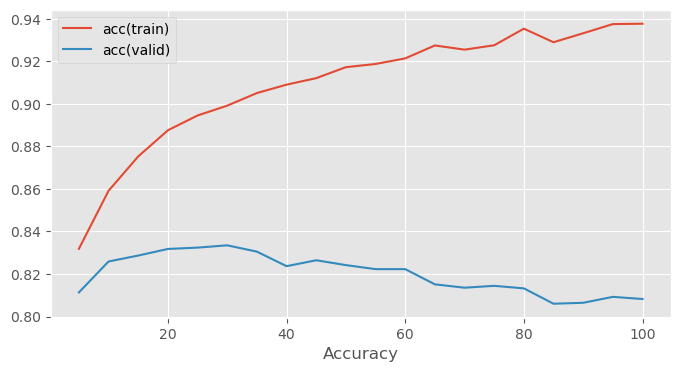

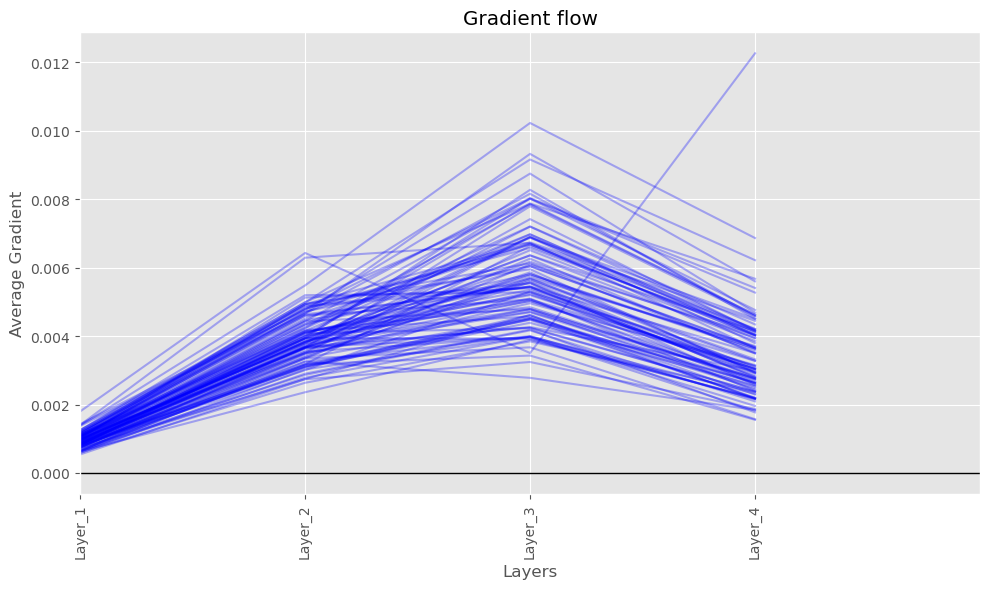

In [17]:
# SINGLE LAYER NETWORK WITH WIDTH 128
%pip install tqdm

# Setup hyperparameters
learning_rate = 0.0009
num_epochs = 100
stats_interval = 5
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_128, keys, run_time, fig_1_128, ax_1_128, fig_2_128, ax_2_128, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

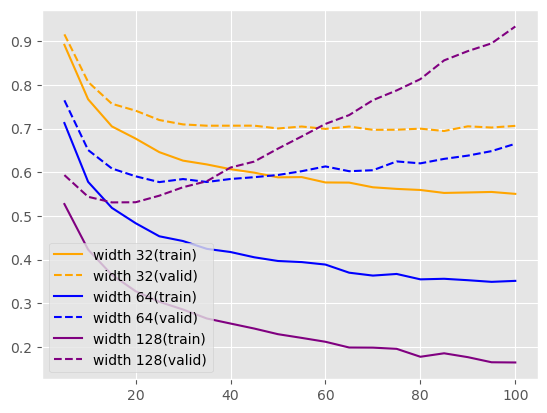

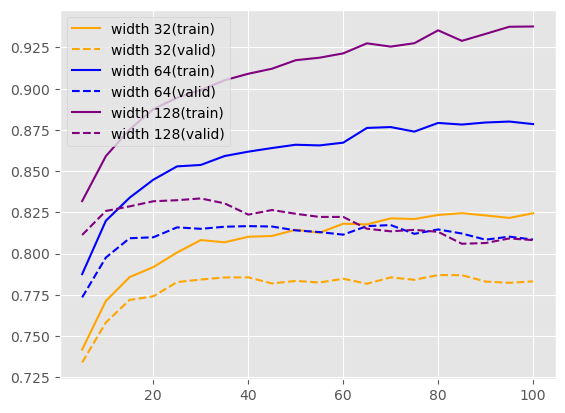

In [18]:
#Plotting all errors in a single figure
width_32_train_error = stats_28[:, 0]
width_32_valid_error = stats_28[:, 2]
width_32_train_acc = stats_28[:, 1]
width_32_valid_acc = stats_28[:, 3]

width_64_train_error = stats_64[:, 0]
width_64_valid_error = stats_64[:, 2]
width_64_train_acc = stats_64[:, 1]
width_64_valid_acc = stats_64[:, 3]

width_128_train_error = stats_128[:, 0]
width_128_valid_error = stats_128[:, 2]
width_128_train_acc = stats_128[:, 1]
width_128_valid_acc = stats_128[:, 3]

epochs = np.arange(5, 105, 5)

fig_errors, ax_error = plt.subplots()

ax_error.plot(epochs, width_32_train_error[1:], label = 'width 32(train)', color = 'orange')
ax_error.plot(epochs, width_32_valid_error[1:], '--', label = 'width 32(valid)', color = 'orange')
ax_error.plot(epochs, width_64_train_error[1:],label = 'width 64(train)', color = 'blue')
ax_error.plot(epochs, width_64_valid_error[1:], '--', label = 'width 64(valid)', color = 'blue')
ax_error.plot(epochs, width_128_train_error[1:],label = 'width 128(train)', color = 'purple')
ax_error.plot(epochs, width_128_valid_error[1:], '--', label = 'width 128(valid)', color = 'purple')
ax_error.legend()

fig_errors.savefig('error_curve_width.png')
plt.show()


fig_accs, ax_accs = plt.subplots()
ax_accs.plot(epochs, width_32_train_acc[1:], label = 'width 32(train)', color = 'orange')
ax_accs.plot(epochs, width_32_valid_acc[1:], '--', label = 'width 32(valid)', color = 'orange')
ax_accs.plot(epochs, width_64_train_acc[1:],label = 'width 64(train)', color = 'blue')
ax_accs.plot(epochs, width_64_valid_acc[1:], '--', label = 'width 64(valid)', color = 'blue')
ax_accs.plot(epochs, width_128_train_acc[1:],label = 'width 128(train)', color = 'purple')
ax_accs.plot(epochs, width_128_valid_acc[1:], '--', label = 'width 128(valid)', color = 'purple')
ax_accs.legend()
fig_accs.savefig('acc_curve_width.png')
plt.show()


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 19.3s to complete
    error(train)=5.29e-01, acc(train)=8.37e-01, error(valid)=5.76e-01, acc(valid)=8.23e-01


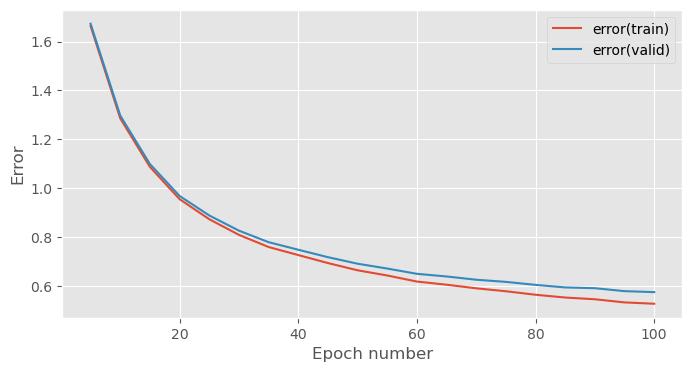

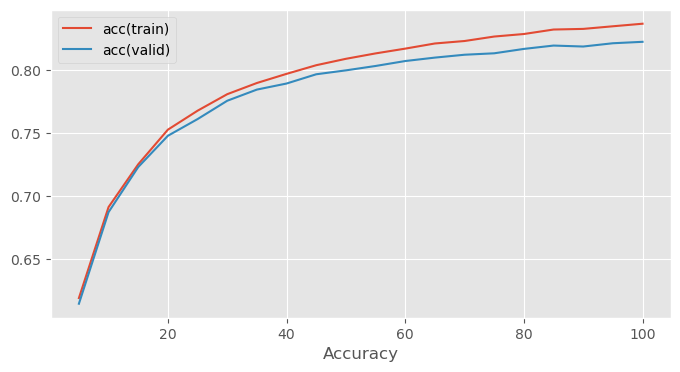

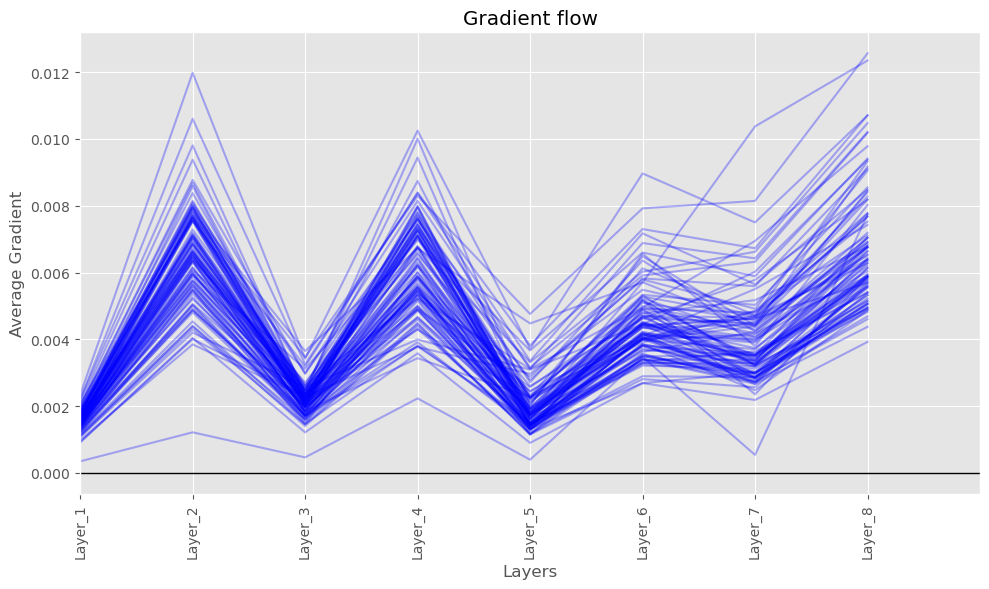

In [5]:
#DROPOUT WITH DROPOUT RATE OF 0.7

# Setup hyperparameters
incl_prob = 0.7
learning_rate = 0.0001
num_epochs = 100
stats_interval = 5
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with three hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init),
    DropoutLayer(rng, incl_prob),
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    DropoutLayer(rng, incl_prob),
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    DropoutLayer(rng, incl_prob),
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init),
    DropoutLayer(rng, incl_prob),
])


error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_dropout, keys, run_time, fig_1_128, ax_1_128, fig_2_128, ax_2_128, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

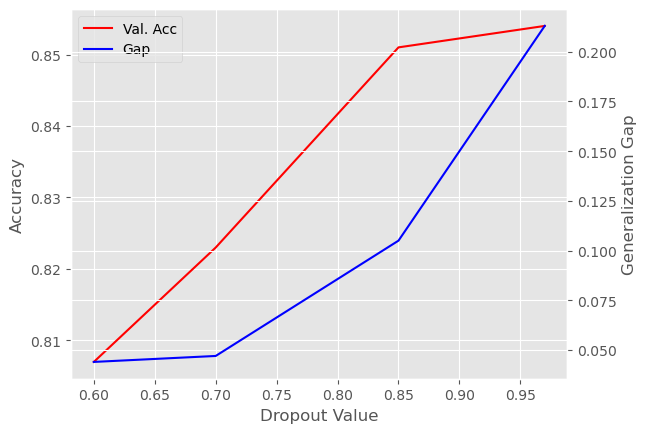

In [9]:
#Plots of generalization gap and validation accuracy for different dropout values
drop_values = [0.6, 0.7, 0.85, 0.97]
val_accs = [0.807, 0.823, 0.851, 0.854]
gen_gaps = [0.044, 0.047, 0.105, 0.213]

fig_d, ax_d = plt.subplots()

# Left axis
ax_d.plot(drop_values, val_accs, 'r', label='Val. Acc')
ax_d.set_ylabel("Accuracy")
ax_d.set_xlabel("Dropout Value")

# Right axis
ax2 = ax_d.twinx()
ax2.plot(drop_values, gen_gaps, 'b', label='Gap')
ax2.set_ylabel("Generalization Gap")

# Combined legend
lines = ax_d.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax_d.legend(lines, labels)

plt.show()
fig_d.savefig('dropout_plot')

In [21]:
# L1 Penalty with 0.005 coefficient 
%pip install tqdm

# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 5
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

penalty_coeff = 0.005


L1Penalty = L1Penalty(penalty_coeff)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1Penalty, biases_penalty=L1Penalty), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1Penalty, biases_penalty=L1Penalty), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1Penalty, biases_penalty=L1Penalty), # third hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=L1Penalty, biases_penalty=L1Penalty) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_L1_penalty, keys, run_time, fig_1_128, ax_1_128, fig_2_128, ax_2_128, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

Note: you may need to restart the kernel to use updated packages.


TypeError: 'numpy.float64' object is not callable

Note: you may need to restart the kernel to use updated packages.


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 10.7s to complete
    error(train)=3.59e-01, acc(train)=8.81e-01, error(valid)=4.52e-01, acc(valid)=8.50e-01


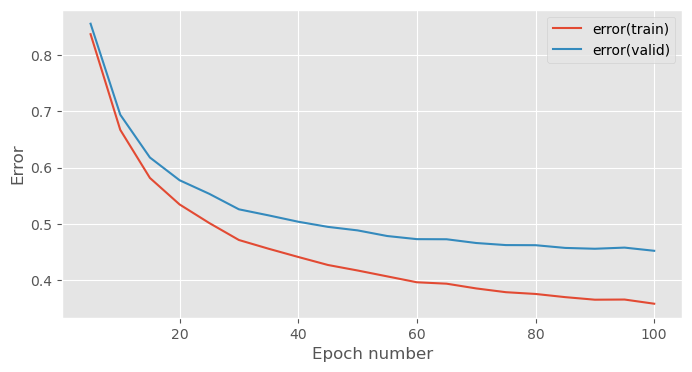

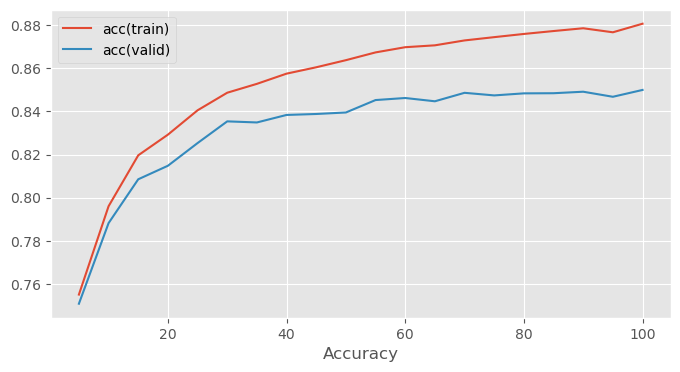

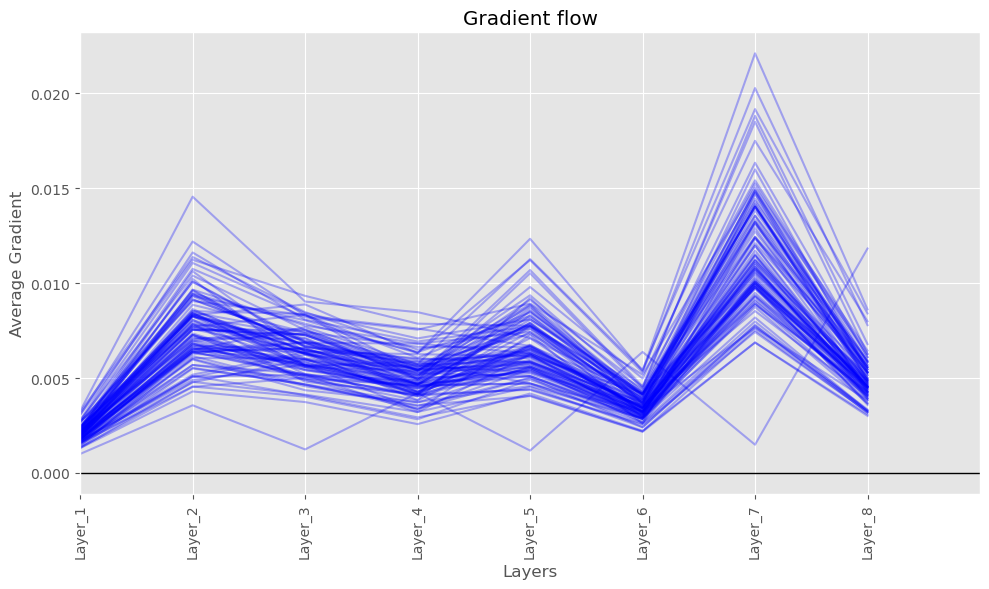

In [6]:
# L2 Penalty with 0.001 coefficient 

# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 5
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

penalty_coeff = 0.001

L2Penalty = L2Penalty(penalty_coeff)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=L2Penalty, biases_penalty=L2Penalty), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L2Penalty, biases_penalty=L2Penalty), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L2Penalty, biases_penalty=L2Penalty), # third hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=L2Penalty, biases_penalty=L2Penalty) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_L1_penalty, keys, run_time, fig_1_128, ax_1_128, fig_2_128, ax_2_128, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

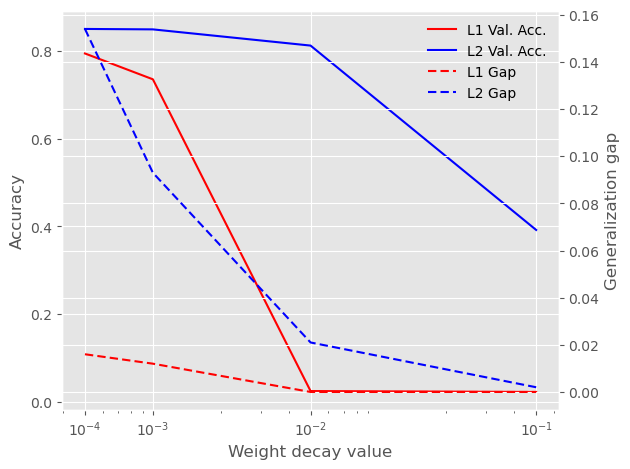

In [15]:
#Plots of accuracy and error by weight penalty 

import matplotlib.pyplot as plt

labels = [r'$10^{-4}$', r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$']
penalties = [0.0005, 0.001, 0.005, 0.05] 
l1_accs = [0.795, 0.736, 0.0241, 0.0220]
l2_accs = [0.851, 0.850, 0.813, 0.392]
l1_gap = [0.016, 0.012, 0, 0]
l2_gap = [0.154, 0.093, 0.021, 0.002]

fig_w, ax_w = plt.subplots()
ax_w2 = ax_w.twinx()

ax_w.semilogx(penalties, l1_accs, color='r', label='L1 Val. Acc.')
ax_w.semilogx(penalties, l2_accs, color='b', label='L2 Val. Acc.')

ax_w2.semilogx(penalties, l1_gap, color='r', linestyle=(0, (4, 2)), label='L1 Gap')
ax_w2.semilogx(penalties, l2_gap, color='b', linestyle=(0, (4, 2)), label='L2 Gap')

ax_w.set_xlabel('Weight decay value')
ax_w.set_ylabel('Accuracy')
ax_w2.set_ylabel('Generalization gap')

ax_w.set_xticks(penalties)
ax_w.set_xticklabels(labels)

lines, labels = ax_w.get_legend_handles_labels()
lines2, labels2 = ax_w2.get_legend_handles_labels()
ax_w.legend(lines + lines2, labels + labels2, loc='best', frameon=False)

plt.tight_layout()
plt.show()

fig_w.savefig('wd_plot')


KeysView(NpzFile 'C:\\Users\\samue\\mlpractical\\data\\emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile 'C:\\Users\\samue\\mlpractical\\data\\emnist-valid.npz' with keys: inputs, targets)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 7.8s to complete
    error(train)=1.01e+00, acc(train)=9.12e-01, error(valid)=5.45e-01, acc(valid)=8.54e-01


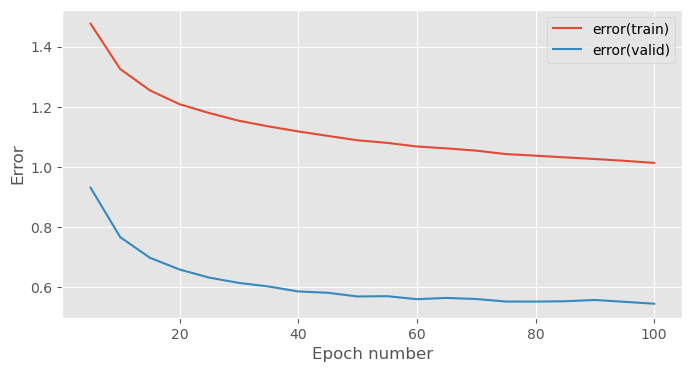

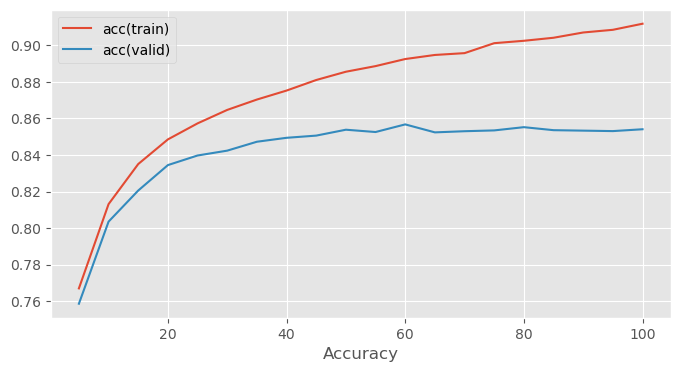

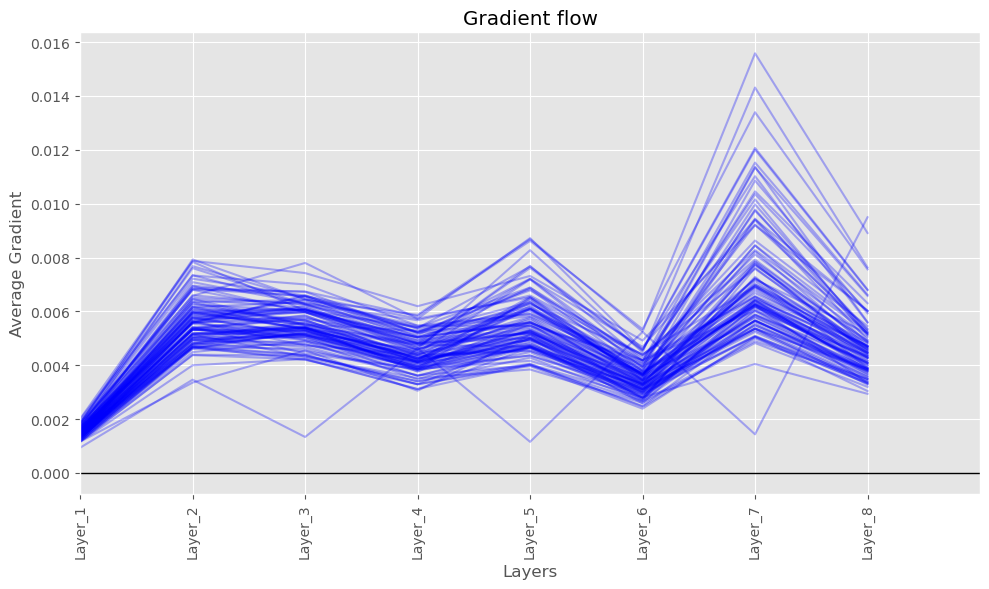

In [5]:
#Label smoothing

seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100

logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng, smooth_labels=True)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 5
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)


# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # third hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_L1_smoothing, keys, run_time, fig_1_128, ax_1_128, fig_2_128, ax_2_128, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)


KeysView(NpzFile 'C:\\Users\\samue\\mlpractical\\data\\emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile 'C:\\Users\\samue\\mlpractical\\data\\emnist-valid.npz' with keys: inputs, targets)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 18.4s to complete
    error(train)=5.07e-01, acc(train)=8.38e-01, error(valid)=5.32e-01, acc(valid)=8.29e-01


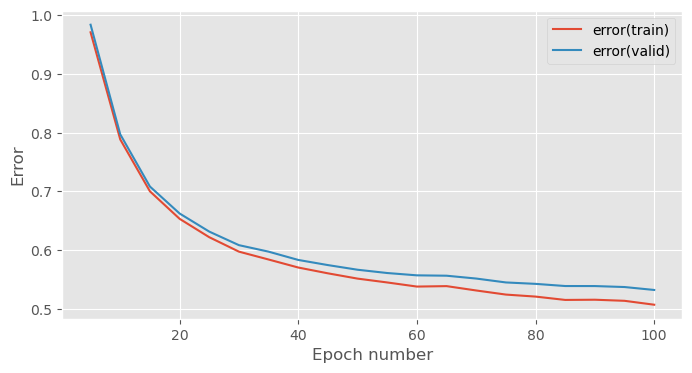

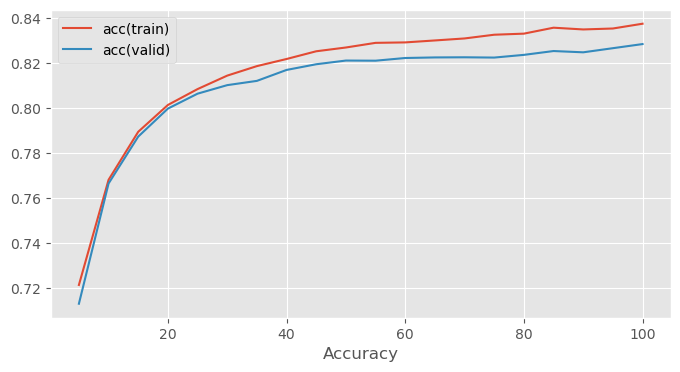

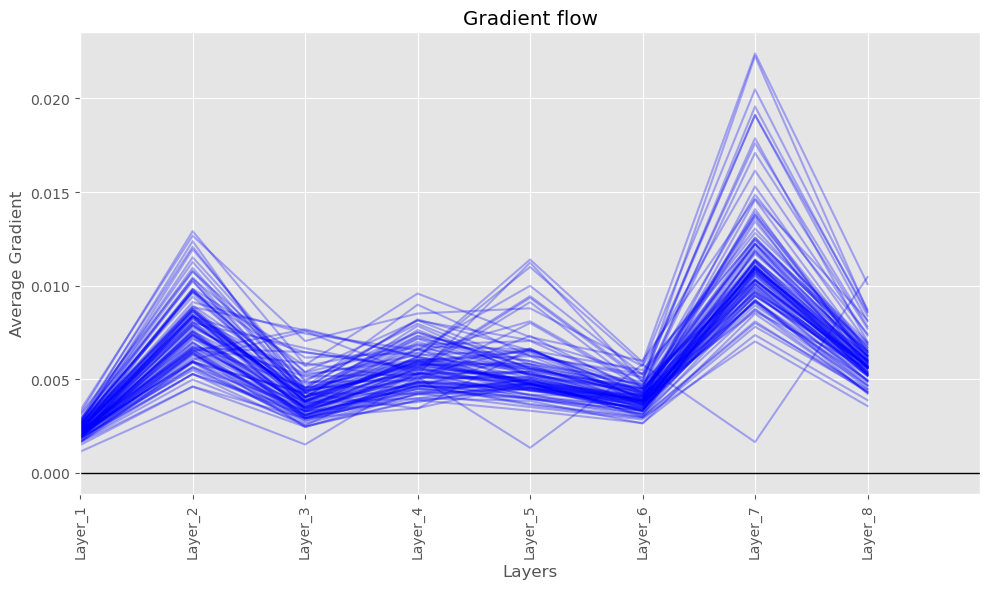

In [3]:
#Elastic Net regression experiment 1, 0.0005 regularization coefficient and equal mixing 
# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

learning_rate = 0.0001
num_epochs = 100
stats_interval = 5
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

reg_coeff = 0.0005
mixing_coeff = 0.5

mix_penalty = L1L2MixPenalty(reg_coeff, mixing_coeff)

# Create model with three hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=mix_penalty, biases_penalty=mix_penalty), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=mix_penalty, biases_penalty=mix_penalty), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=mix_penalty, biases_penalty=mix_penalty), # third hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=mix_penalty, biases_penalty=mix_penalty) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_mix_penalty1, keys, run_time, fig_1_128, ax_1_128, fig_2_128, ax_2_128, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

KeysView(NpzFile 'C:\\Users\\samue\\mlpractical\\data\\emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile 'C:\\Users\\samue\\mlpractical\\data\\emnist-valid.npz' with keys: inputs, targets)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 17.6s to complete
    error(train)=6.57e-01, acc(train)=7.99e-01, error(valid)=6.68e-01, acc(valid)=7.94e-01


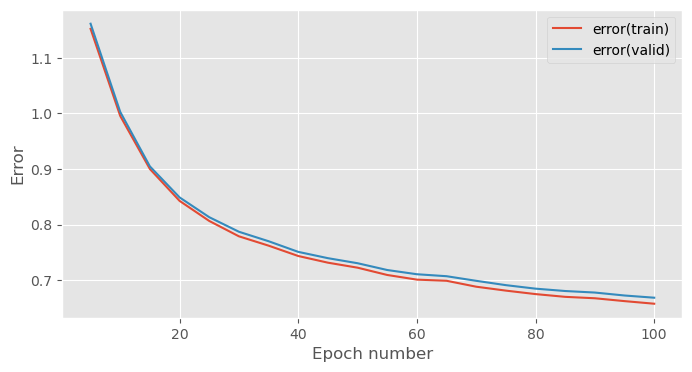

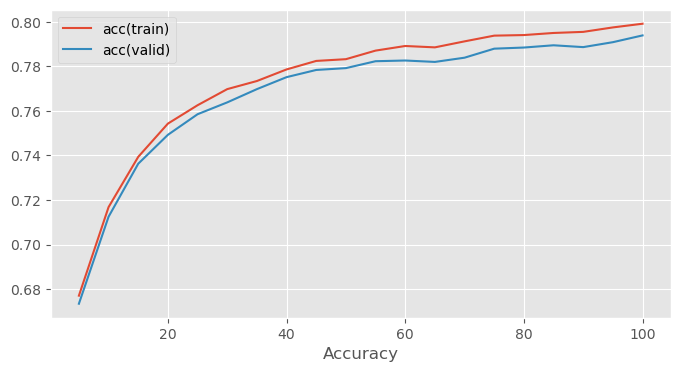

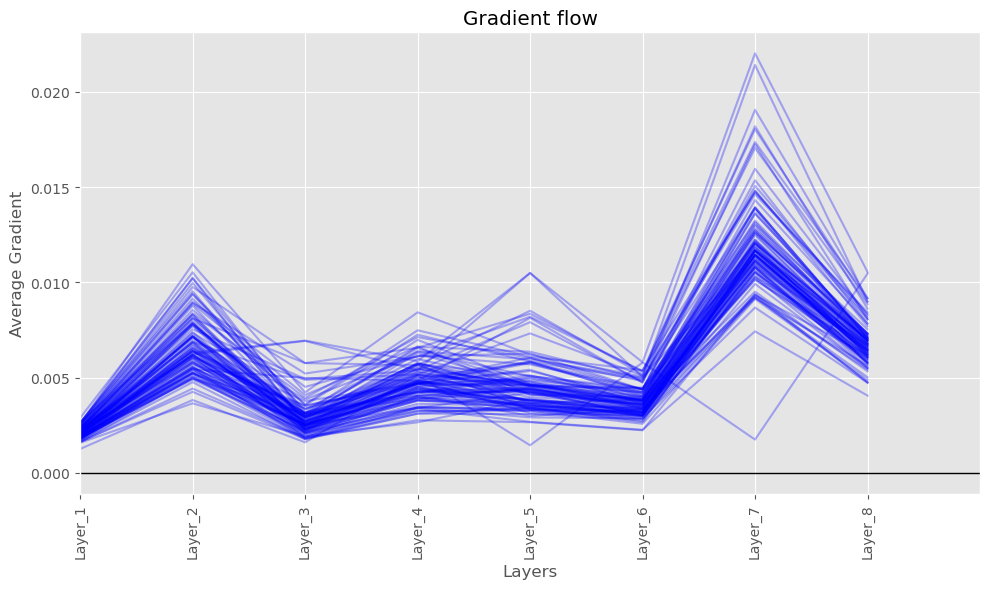

In [4]:
#Elastic Net regression experiment 2, 0.001 regularization coefficient and equal mixing 
# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

learning_rate = 0.0001
num_epochs = 100
stats_interval = 5
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

reg_coeff = 0.001
mixing_coeff = 0.5

L1L2MixPenalty = L1L2MixPenalty(reg_coeff, mixing_coeff)

# Create model with three hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1L2MixPenalty, biases_penalty=L1L2MixPenalty), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1L2MixPenalty, biases_penalty=L1L2MixPenalty), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1L2MixPenalty, biases_penalty=L1L2MixPenalty), # third hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=L1L2MixPenalty, biases_penalty=L1L2MixPenalty) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_mix_penalty2, keys, run_time, fig_1_128, ax_1_128, fig_2_128, ax_2_128, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

KeysView(NpzFile 'C:\\Users\\samue\\mlpractical\\data\\emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile 'C:\\Users\\samue\\mlpractical\\data\\emnist-valid.npz' with keys: inputs, targets)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 17.8s to complete
    error(train)=4.36e-01, acc(train)=8.58e-01, error(valid)=4.79e-01, acc(valid)=8.43e-01


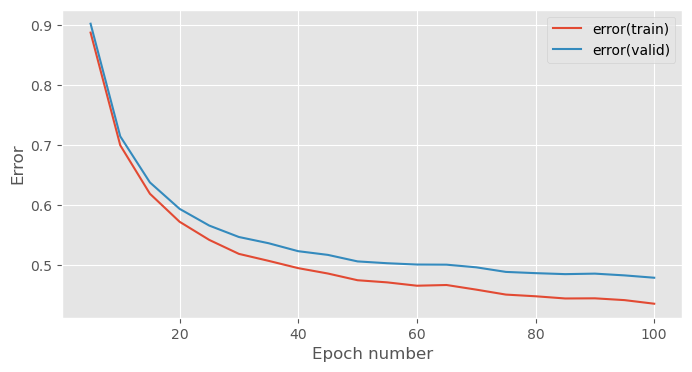

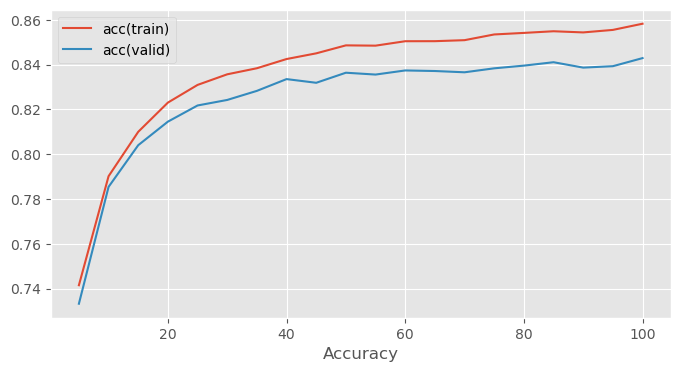

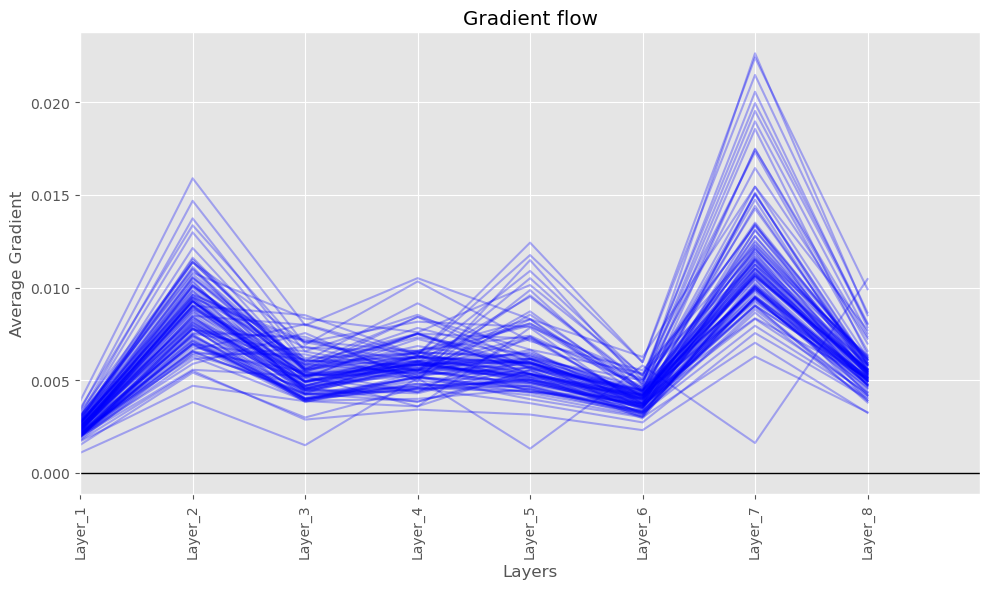

In [3]:
#Elastic Net regression experiment 3, 0.0005 regularization coefficient and 0.25 mixing 
# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

learning_rate = 0.0001
num_epochs = 100
stats_interval = 5
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

reg_coeff = 0.0005
mixing_coeff = 0.25

L1L2MixPenalty = L1L2MixPenalty(reg_coeff, mixing_coeff)

# Create model with three hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1L2MixPenalty, biases_penalty=L1L2MixPenalty), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1L2MixPenalty, biases_penalty=L1L2MixPenalty), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1L2MixPenalty, biases_penalty=L1L2MixPenalty), # third hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=L1L2MixPenalty, biases_penalty=L1L2MixPenalty) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_mix_penalty2, keys, run_time, fig_1_128, ax_1_128, fig_2_128, ax_2_128, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

KeysView(NpzFile 'C:\\Users\\samue\\mlpractical\\data\\emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile 'C:\\Users\\samue\\mlpractical\\data\\emnist-valid.npz' with keys: inputs, targets)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 17.5s to complete
    error(train)=3.68e-01, acc(train)=8.78e-01, error(valid)=4.51e-01, acc(valid)=8.52e-01


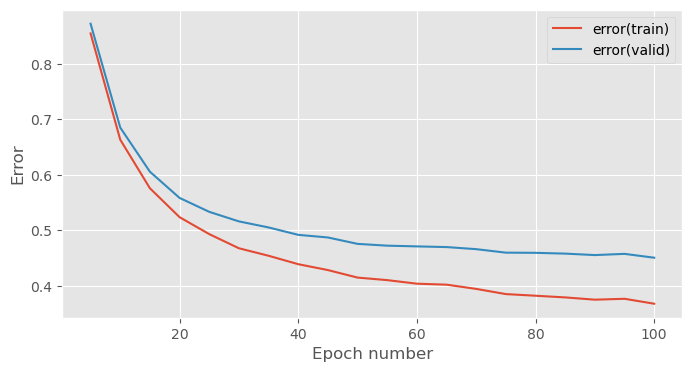

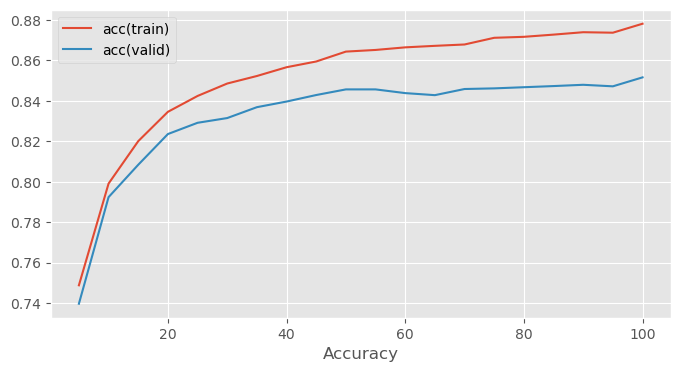

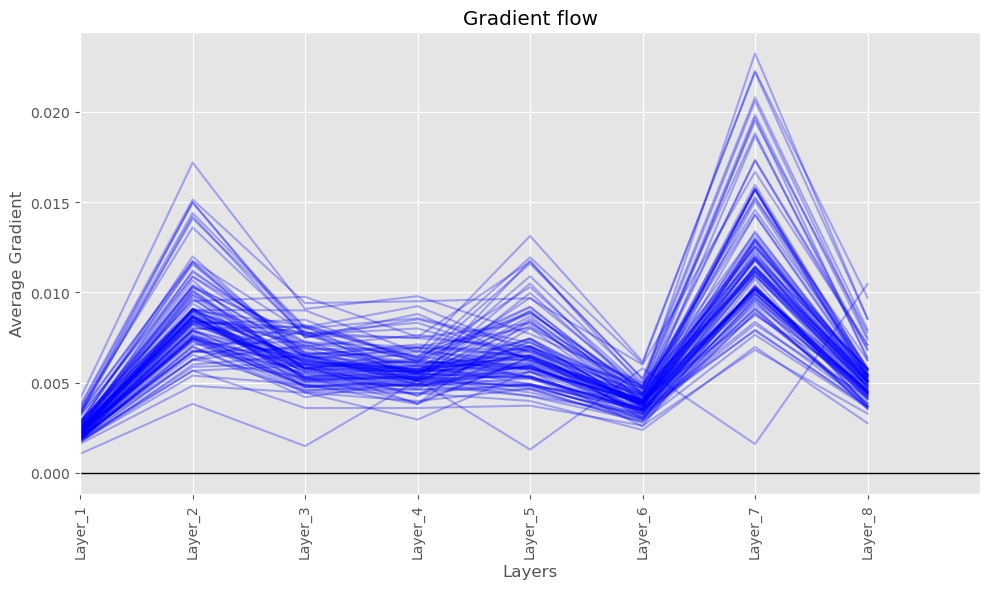

In [3]:
#Elastic Net regression experiment 4, 0.0005 regularization coefficient and 0.1 mixing 
# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

learning_rate = 0.0001
num_epochs = 100
stats_interval = 5
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

reg_coeff = 0.0005
mixing_coeff = 0.1

L1L2MixPenalty = L1L2MixPenalty(reg_coeff, mixing_coeff)

# Create model with three hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1L2MixPenalty, biases_penalty=L1L2MixPenalty), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1L2MixPenalty, biases_penalty=L1L2MixPenalty), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1L2MixPenalty, biases_penalty=L1L2MixPenalty), # third hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=L1L2MixPenalty, biases_penalty=L1L2MixPenalty) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_mix_penalty3, keys, run_time, fig_1_128, ax_1_128, fig_2_128, ax_2_128, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

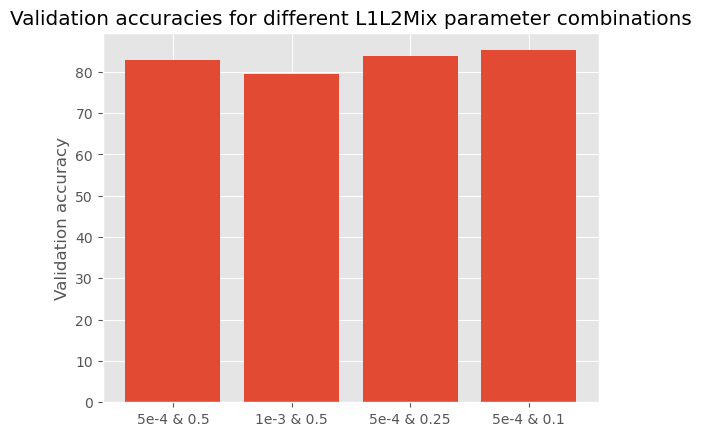

In [12]:
#Figures depicting validation accuracy and generalisation gap for elastic net experiments

valid_accs = [82.9, 79.4, 83.9, 85.2]
labels = ['5e-4 & 0.5', '1e-3 & 0.5', '5e-4 & 0.25', '5e-4 & 0.1']

fig, ax = plt.subplots()

ax.bar(labels, valid_accs)
ax.set_ylabel('Validation accuracy')
ax.set_title('Validation accuracies for different L1L2Mix parameter combinations')
plt.show()

fig.savefig('l1l2mix_valid_accs')


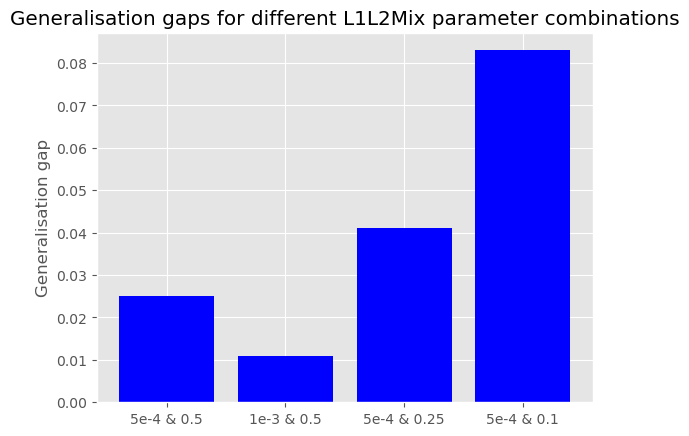

In [13]:
gen_gaps = np.array([0.532, 0.668, 0.483, 0.451]) - np.array([0.507, 0.657, 0.442, 0.368])
labels = ['5e-4 & 0.5', '1e-3 & 0.5', '5e-4 & 0.25', '5e-4 & 0.1']

fig, ax = plt.subplots()

ax.bar(labels, gen_gaps, color='blue')
ax.set_ylabel('Generalisation gap')
ax.set_title('Generalisation gaps for different L1L2Mix parameter combinations')
plt.show()

fig.savefig('l1l2mix_gen_gaps')

## Problematic Training

The following experiments show a failed training run. Run the code and investigate the reasons.

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 15.5s to complete
    error(train)=3.85e+00, acc(train)=2.12e-02, error(valid)=3.85e+00, acc(valid)=2.22e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 14.3s to complete
    error(train)=3.85e+00, acc(train)=2.12e-02, error(valid)=3.85e+00, acc(valid)=2.10e-02


...

Epoch 3: 14.9s to complete
    error(train)=3.85e+00, acc(train)=2.15e-02, error(valid)=3.85e+00, acc(valid)=1.99e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 4: 18.0s to complete
    error(train)=3.85e+00, acc(train)=2.17e-02, error(valid)=3.85e+00, acc(valid)=1.98e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5: 17.8s to complete
    error(train)=3.85e+00, acc(train)=2.15e-02, error(valid)=3.85e+00, acc(valid)=2.04e-02


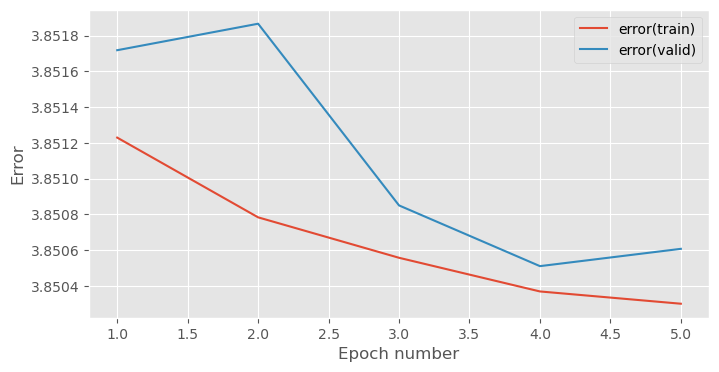

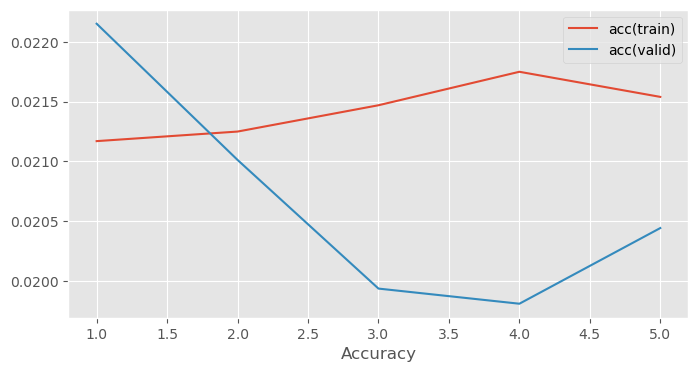

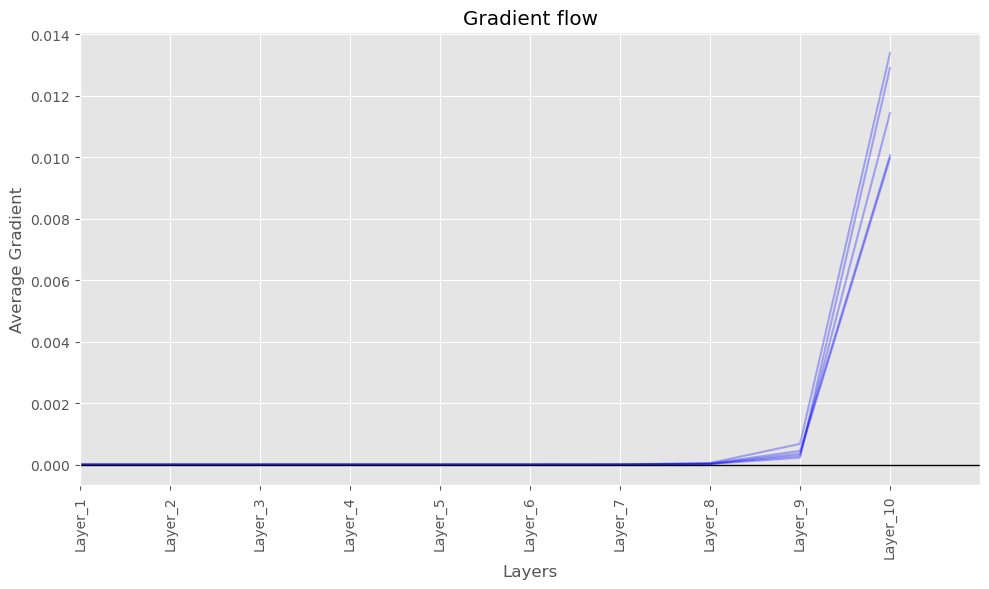

In [4]:
# Setup hyperparameters
learning_rate = 0.001
num_epochs = 5
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with four hidden layer
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    CustomActivationLayer(), 
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

In [7]:
# You can then check the plots like this
fig_1 # The training error plot
fig_1.savefig('custom_act_error')

In [10]:
fig_2 # The training accuracy plot
fig_2.savefig('custom_act_acc')

In [12]:
grad_plot # The gradient flow plot
grad_plot.savefig('grad_plot_custom_act')